# Análise Estatística do Baseline (Estratégia 1)

Este notebook realiza uma análise profunda dos resultados obtidos pela extração de características 1D (Tempo + Frequência) aliados a modelos clássicos e de Deep Learning Tabular.
Como a tarefa de **Detecção** obteve resultados próximos a 100% de forma unânime, nossa análise estatística focará na tarefa mais desafiadora: o **Diagnóstico Multiclasse**.

**Método Estatístico:**
1. **Teste de Friedman:** Um teste não-paramétrico usado para detectar diferenças nos tratamentos através de múltiplas tentativas de teste (perfeito para comparar modelos de ML em múltiplas dobras).
2. **Teste de Wilcoxon (Post-Hoc):** Caso o teste de Friedman aponte uma diferença significativa, faremos testes pareados para provar que a arquitetura proposta (TabNet) é estatisticamente superior (ou equivalente) aos baselines (Random Forest e SVM).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon

# Configuração de estilo para artigos científicos
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Carregar os resultados
ARQUIVO_CSV = '../results/resultados_master_V2_20260629_174206.csv'
df = pd.read_csv(ARQUIVO_CSV)

# 2. Filtrar apenas a tarefa de Diagnóstico
df_diag = df[df['Task'] == 'Diagnosis'].copy()

# Converter F1 para porcentagem para facilitar a leitura visual
df_diag['Macro F1 (%)'] = df_diag['Macro F1'] * 100

print(f"Total de amostras de diagnóstico (Folds avaliados): {len(df_diag) // 3}")
df_diag.head()

Total de amostras de diagnóstico (Folds avaliados): 26


,Dataset,Task,Fold,Model,Bal Acc,Macro F1,ROC-AUC,Macro F1 (%)
25,UORED,Diagnosis,Group_A,Random Forest,0.529190,0.479402,0.770059,47.940206
26,UORED,Diagnosis,Group_A,SVM (RBF),0.362408,0.276430,0.796779,27.643034
27,UORED,Diagnosis,Group_A,TabNet,0.461081,0.378626,0.704089,37.862588
28,UORED,Diagnosis,Group_A,FT-Transformer,0.446429,0.379116,0.757806,37.911640
29,UORED,Diagnosis,Group_A,TabNet-ResNet1D,0.541209,0.461654,0.684267,46.165363


/tmp/ipykernel_69549/3747819594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Model', y='Macro F1 (%)', data=df_diag, palette='light:gray', showfliers=False)


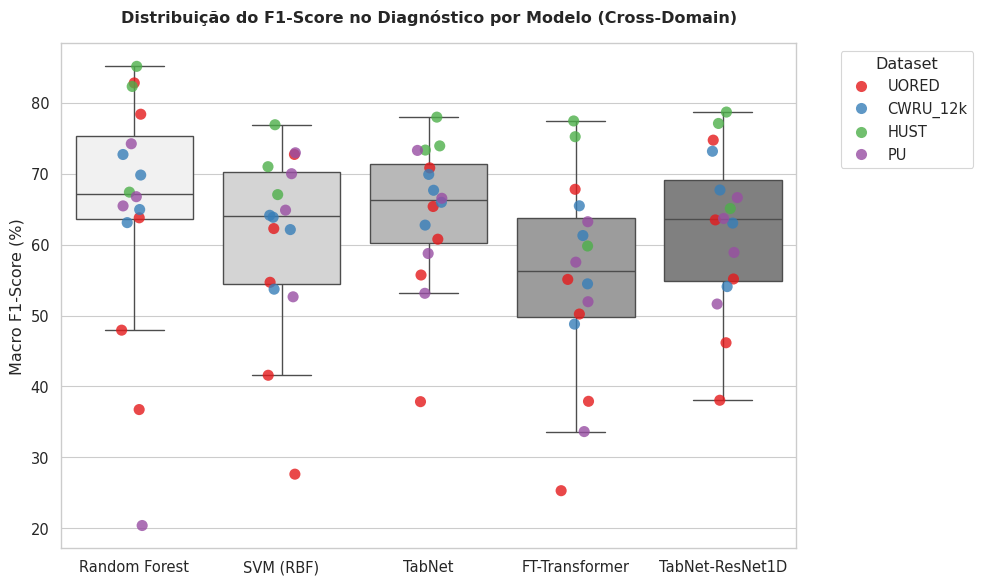

In [2]:
plt.figure(figsize=(10, 6))

# Boxplot para mostrar a mediana e quartis
ax = sns.boxplot(x='Model', y='Macro F1 (%)', data=df_diag, palette='light:gray', showfliers=False)

# Stripplot para mostrar cada fold individualmente como um ponto
sns.stripplot(x='Model', y='Macro F1 (%)', data=df_diag, hue='Dataset', 
              palette='Set1', size=8, alpha=0.8, jitter=True, ax=ax)

plt.title('Distribuição do F1-Score no Diagnóstico por Modelo (Cross-Domain)', pad=15, fontweight='bold')
plt.ylabel('Macro F1-Score (%)')
plt.xlabel('')
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### 🔬 Aplicação dos Testes Estatísticos

Para aplicar o Teste de Friedman, precisamos "parear" os resultados. Isso significa que o modelo A, B e C precisam ser comparados exatamente na mesma dobra (ex: fold `Load_0W` da base `HUST`).

In [5]:
# 1. Definição dinâmica de modelos
# Adicione ou remova modelos desta lista conforme necessário.
modelos = ['Random Forest', 'SVM (RBF)', 'FT-Transformer', 'TabNet', 'TabNet-ResNet1D']
modelo_proposto = 'TabNet' # O modelo que será comparado contra os baselines

# Pivotar a tabela para garantir o pareamento rigoroso
# Filtramos apenas os modelos da nossa lista para evitar colunas indesejadas
df_pareado = df_diag.pivot(index=['Dataset', 'Fold'], columns='Model', values='Macro F1 (%)')[modelos].dropna()

print("--- Tabela Pareada de Experimentos (Amostra) ---")
print(df_pareado.head(), "\n")

# 2. Executar o Teste de Friedman de forma dinâmica
# Criamos uma lista de Séries do Pandas e usamos o * para desempacotá-la como argumentos
dados_modelos = [df_pareado[modelo] for modelo in modelos]
stat_f, p_friedman = friedmanchisquare(*dados_modelos)

print("-" * 50)
print(f"Teste de Friedman | Estatística: {stat_f:.3f} | p-value: {p_friedman:.5f}")

if p_friedman < 0.05:
    print(f"CONCLUSÃO FRIEDMAN: Existe uma diferença ESTATISTICAMENTE SIGNIFICATIVA entre os {len(modelos)} modelos (p < 0.05).")
    print("Podemos avançar para o teste Post-Hoc.\n")
    
    # 3. Teste de Wilcoxon Pareado (Comparando com a Proposta)
    print(f"--- Teste Post-Hoc de Wilcoxon ({modelo_proposto} vs Baselines) ---")
    
    # Criamos uma lista apenas com os modelos baseline (removendo o modelo proposto)
    baselines = [modelo for modelo in modelos if modelo != modelo_proposto]
    
    # Iteramos sobre cada baseline de forma dinâmica
    for baseline in baselines:
        stat_w, p_w = wilcoxon(df_pareado[modelo_proposto], df_pareado[baseline])
        
        print(f"\n{modelo_proposto} vs {baseline:<15} : p-value = {p_w:.5f}")
        
        if p_w < 0.05:
            # Aqui assumimos que maior Macro F1 é melhor. Se precisar validar a média, você pode checar:
            # if df_pareado[modelo_proposto].mean() > df_pareado[baseline].mean():
            print(f" -> {modelo_proposto} é estatisticamente SUPERIOR ao {baseline}.")
        else:
            print(f" -> Não há diferença estatística significativa entre {modelo_proposto} e {baseline}.")

else:
    print("CONCLUSÃO: Não há diferença estatisticamente significativa entre os modelos. Eles empatam estatisticamente.")
print("-" * 50)

--- Tabela Pareada de Experimentos (Amostra) ---
Model              Random Forest  SVM (RBF)  FT-Transformer     TabNet  \
Dataset  Fold                                                            
CWRU_12k Load_0HP      63.098258  53.716814       48.791576  62.748572   
         Load_1HP      69.804555  62.117032       61.278356  67.657669   
         Load_2HP      72.700765  63.857144       65.467916  69.895227   
         Load_3HP      64.944602  64.131660       54.470588  65.965439   
HUST     Load_0W       67.396035  67.047620       59.802223  73.324403   

Model              TabNet-ResNet1D  
Dataset  Fold                       
CWRU_12k Load_0HP        54.080746  
         Load_1HP        63.031811  
         Load_2HP        67.696904  
         Load_3HP        73.158726  
HUST     Load_0W         65.088304   

--------------------------------------------------
Teste de Friedman | Estatística: 25.400 | p-value: 0.00004
CONCLUSÃO FRIEDMAN: Existe uma diferença ESTATISTICAMENTE SIG